# Product Description Clustering & Recommendation System

## Introduction

### Project goal

The goal of this project is to analyze product descriptions with NLP in order to group similar items and generate product recommendations.

### Why this project?

Product catalogs can be large and difficult to explore manually.  
Using text analysis makes it possible to:

- find similar products automatically,
- better understand the structure of the catalog,
- create a simple recommendation system based on product descriptions.

### Target audience

This project may be useful for:

- **users** looking for similar products,
- **product and marketing teams** who want to better organize and understand the catalog.

### Workflow

1. exploratory data analysis,
2. text preprocessing,
3. TF-IDF vectorization and dimensionality reduction,
4. clustering with KMeans and DBSCAN,
5. recommendation based on product similarity,
6. final interpretation.

In [ ]:
#!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import en_core_web_sm
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

import matplotlib.pyplot as plt

from wordcloud import WordCloud
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


## 1. Exploratory Data Analysis (EDA)

### Goal

Before applying any NLP methods, the first step is to explore the dataset and understand its structure.

This helps confirm that the data is usable, identify the main columns, and check for missing values or other basic data quality issues.

### What was done

In this section, we:

1. loaded the dataset from `data.csv`,
2. displayed the first rows to get a quick overview,
3. checked the structure of the dataset and column types,
4. reviewed missing values across the columns.

In [11]:
data = pd.read_csv('data.csv')
data.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           500 non-null    int64 
 1   description  500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


In [13]:
data.isnull().sum() / len(data) * 100

id             0.0
description    0.0
dtype: float64

### First observations

- The dataset contains **500 products**, with one unique `id` and one text description for each item.
- No missing values were found in the main columns.
- The data types are consistent with the expected structure of the dataset.

Overall, the dataset is clean and ready for text preprocessing.

## 2. NLP Preprocessing of Product Descriptions

### Goal

The goal of this step is to clean and standardize product descriptions before turning them into numerical features.

This is important because raw text often contains noise such as punctuation, formatting issues, or very common words that do not add much meaning.

### What was done

In this section, we:

1. **cleaned the product descriptions**
   - removed HTML tags and unwanted characters,
   - converted text to lowercase,
   - normalized extra spaces,

2. **processed the text with NLP tools**
   - lemmatized the words,
   - removed stopwords and low-information terms,

3. **created intermediate cleaned text columns**
   - to keep track of each preprocessing stage,

4. **prepared the final text for vectorization**
   - using a cleaned version of the descriptions ready for TF-IDF.

In [14]:
data["desc_clean"] = (
    data["description"]
    .fillna("")
    .str.replace(r"<[^>]*>", " ", regex=True)
    .str.replace(r"[^A-Za-z0-9 ]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
    .str.strip()
)

data[["description", "desc_clean"]].head()

,description,desc_clean
0,Active classic boxers - There's a reason why o...,active classic boxers there s a reason why our...
1,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...
2,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...
3,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...
4,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...


In [15]:
nlp = en_core_web_sm.load()

In [16]:
data["desc_token_temp"] = data["desc_clean"].apply(
    lambda x: [
        token.lemma_.lower()
        for token in nlp(x)
        if token.text.lower() not in STOP_WORDS
        and len(token.text) > 2
    ]
)

data["nlp_ready_temp"] = data["desc_token_temp"].apply(lambda tokens: " ".join(tokens))

vectorizer_temp = TfidfVectorizer()
X_temp = vectorizer_temp.fit_transform(data["nlp_ready_temp"])

feature_names = vectorizer_temp.get_feature_names_out()
mean_tfidf = X_temp.mean(axis=0).A1

count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(data["nlp_ready_temp"])

doc_freq = np.asarray((X_count > 0).sum(axis=0)).ravel() / X_count.shape[0]

words_high_freq = [
    word for word, freq in zip(count_vectorizer.get_feature_names_out(), doc_freq)
    if freq > 0.7
]

threshold = 0.008
low_info_words = [
    word for word, score in zip(feature_names, mean_tfidf)
    if score < threshold
]

combined_stopwords = STOP_WORDS.union(words_high_freq).union(low_info_words)

data["desc_token"] = data["desc_token_temp"].apply(
    lambda tokens: [token for token in tokens if token not in combined_stopwords]
)

data["nlp_ready"] = data["desc_token"].apply(lambda tokens: " ".join(tokens))

final_vectorizer = TfidfVectorizer()
X = final_vectorizer.fit_transform(data["nlp_ready"])

X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14714 stored elements and shape (500, 187)>

The descriptions were first lemmatized and lightly cleaned to create a temporary corpus.

This intermediate version was then used to identify very frequent and low-information words.  
After removing these terms, a final cleaned corpus was built and transformed into a TF-IDF matrix for the next modeling steps.

The preprocessing step transformed highly variable raw text into a more homogeneous and clean structure, ready to be used by clustering and dimensionality reduction algorithms.
The resulting TF-IDF matrix contains 187 dimensions (retained words) and 500 rows (products), demonstrating a good balance between noise filtering and the preservation of meaningful semantic information.

## 3. TF-IDF Vectorization and Dimensionality Reduction with TruncatedSVD

### Goal

The goal of this step is to convert product descriptions into numerical features and then reduce the dimensionality of this representation.

This makes the text easier to analyze and helps capture broader semantic patterns across products.

### What was done

1. **Vectorized the cleaned descriptions with TF-IDF**  
   The `nlp_ready` column was transformed into a TF-IDF matrix.

2. **Reduced dimensionality with TruncatedSVD**  
   A lower-dimensional representation was created to keep the main structure of the data while reducing noise and sparsity.

3. **Built a topic-based representation**  
   The reduced matrix was stored in a DataFrame so that each product could be described through a smaller set of latent components.

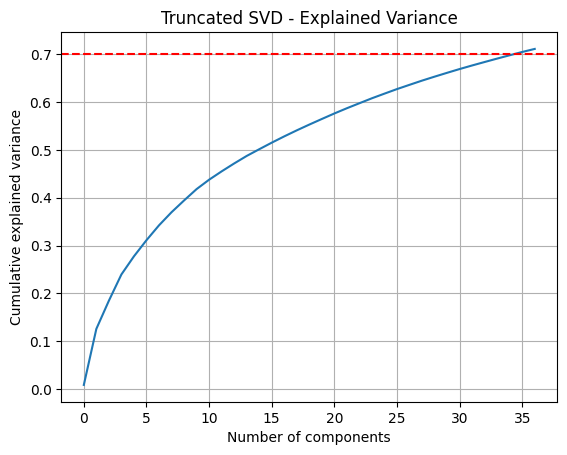

In [ ]:
#Exploratory SVD to inspect explained variance

svd = TruncatedSVD(n_components=37)
svd.fit(X)

explained = np.cumsum(svd.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid()
plt.title("Truncated SVD - Explained Variance")
plt.axhline(0.70, color='red', linestyle='--')
plt.show()

In [ ]:
#Final SVD model with the selected number of components

svd_components = 37
svd_model = TruncatedSVD(n_components=svd_components, algorithm='randomized', n_iter=100)
lsa = svd_model.fit_transform(X)
lsa

array([[ 0.32983924, -0.1375924 , -0.08201786, ..., -0.07999667,
         0.10103591, -0.02572959],
       [ 0.36438521, -0.14003052,  0.00909922, ..., -0.00439547,
         0.03634154,  0.01209725],
       [ 0.32453715, -0.16417689, -0.09329828, ...,  0.03412931,
        -0.11076206, -0.00416874],
       ...,
       [ 0.39496176, -0.28810571, -0.21682248, ..., -0.07100784,
         0.05125061, -0.14370572],
       [ 0.43163326,  0.0627277 ,  0.50416457, ...,  0.05593011,
        -0.01013376, -0.11144195],
       [ 0.45343257,  0.02538329,  0.52802628, ...,  0.02252784,
        -0.03250295, -0.02713098]], shape=(500, 37))

In [10]:
topic_df = pd.DataFrame(lsa, columns=["topic {}".format(i+1) for i in range(svd_components)], index=data.index)
topic_df['desc'] = data['nlp_ready'].values
topic_df

,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9,topic 10,...,topic 29,topic 30,topic 31,topic 32,topic 33,topic 34,topic 35,topic 36,topic 37,desc
0,0.342381,-0.152971,-0.296783,-0.136954,-0.119574,0.173444,-0.092567,0.126531,-0.331156,-0.053193,...,0.101113,0.153425,-0.032186,-0.000596,0.016689,0.041722,0.060330,-0.063686,-0.077238,classic s cool quick lightweight pack waistban...
1,0.409749,-0.152708,-0.233713,0.034544,0.089636,0.026922,-0.206995,0.155338,-0.173261,0.034530,...,0.026379,-0.073997,0.081000,0.136066,-0.148236,-0.045440,0.034066,-0.080390,0.056515,skin breathable s fast dry 7 spandex stretch w...
2,0.346395,-0.161483,-0.086705,-0.090590,0.168399,-0.108168,-0.174078,0.241944,-0.004578,-0.061349,...,-0.087118,-0.174937,-0.054479,0.090652,-0.039238,-0.047430,-0.004127,-0.008412,0.070018,fly s high blend fast quick 7 spandex stretch ...
3,0.438674,-0.269930,0.258325,0.004507,0.090862,0.015718,-0.075423,-0.047254,-0.098618,0.044749,...,0.150868,0.027599,0.062074,-0.092580,-0.173663,-0.132092,0.036034,-0.075262,-0.084866,skin resistant breathable shell stretch t inte...
4,0.482924,-0.273053,0.331598,-0.115396,0.070579,-0.027859,-0.051341,0.111964,-0.014639,0.050795,...,-0.039791,-0.096529,-0.103841,-0.064394,-0.084627,0.073689,-0.086059,-0.119224,-0.003533,wind high shell cool high s time tie ripstop s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.314925,-0.129449,-0.312642,-0.329412,-0.199043,0.151065,-0.037692,0.076791,-0.509215,-0.073718,...,0.014671,-0.026391,0.006762,-0.055102,0.020330,0.021697,0.025196,0.062837,-0.013272,2 capilene 2 fast performance lightweight t op...
496,0.343245,-0.117502,-0.291166,-0.504213,-0.248245,0.130426,0.034594,0.115824,-0.331411,-0.151157,...,-0.082255,-0.153397,0.093675,-0.061050,0.001350,-0.027045,-0.022859,-0.109534,0.016692,2 fast dry time performance open knit construc...
497,0.352357,-0.239697,0.412192,-0.109831,-0.023030,0.112703,0.171632,-0.377059,-0.038140,-0.001517,...,-0.007330,-0.061322,0.092471,-0.059210,-0.036399,0.175164,-0.123994,0.029071,-0.000076,time shell time time finish shell provide leng...
498,0.281547,-0.115655,-0.309882,0.385487,-0.158051,0.291499,0.065517,0.045330,-0.027205,-0.046614,...,-0.024579,-0.036997,0.179519,0.083111,-0.015363,-0.102692,-0.085222,-0.012794,0.002067,wear wear time garment wash 5 2 canvas t chafe...


- The **cumulative explained variance** graph shows a gradual increase, with the 70% threshold reached around 37 components.
- Each description is now represented as a combination of **37 thematic dimensions**, which will later allow for dominant content analysis and visual projections.
- This format is also useful for downstream tasks such as clustering or advanced visualizations (e.g., PCA, t-SNE).

This step validates the construction of a reduced semantic space, ready to be used for **further analysis**.

## 4. Product Clustering with KMeans and DBSCAN

### Goal

The goal of this step is to group products based on the similarity of their descriptions.

This makes it possible to organize the catalog into coherent groups, identify common themes, and compare different clustering approaches.

### What was done

1. **Applied KMeans clustering**
   - tested several values of `k`,
   - compared the results with the silhouette score,
   - selected the most relevant number of clusters.

2. **Applied DBSCAN clustering**
   - tested different values of `eps` and `min_samples`,
   - used cosine distance to better match the TF-IDF representation,
   - compared the resulting cluster structures.

3. **Interpreted the clusters**
   - visualized the groups,
   - and used word clouds to better understand the main themes within each cluster.

#### KMeans

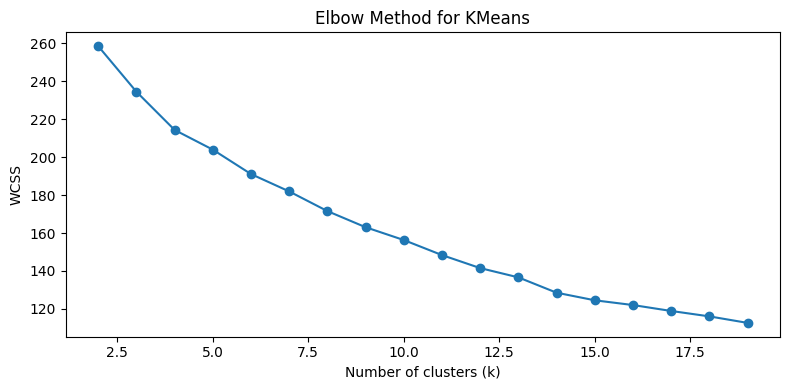

In [21]:
wcss = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(lsa)
    wcss.append(kmeans.inertia_)



plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for KMeans")
plt.tight_layout()
plt.show()

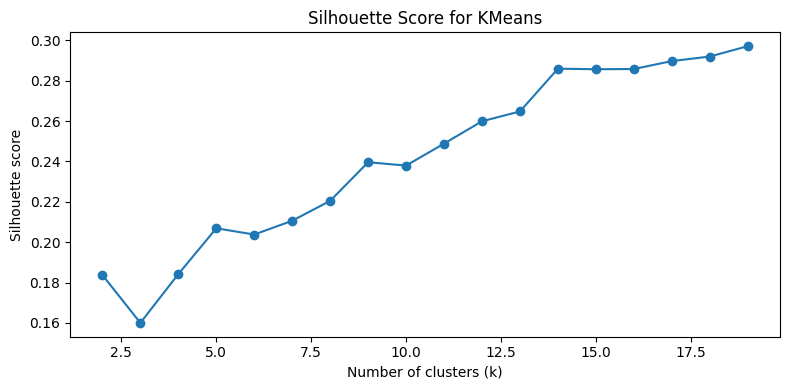

In [22]:
s_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(lsa)
    s_scores.append(silhouette_score(lsa, labels))


plt.figure(figsize=(8, 4))
plt.plot(k_range, s_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score for KMeans")
plt.tight_layout()
plt.show()

To complement the elbow method, the silhouette score was computed for several values of `k`.

This metric helps evaluate how well the clusters are separated and how coherent they are internally.

Two values were considered for KMeans.

A larger number of clusters such as **k = 14** can be justified by the **silhouette score**, which keeps improving as `k` increases. This suggests that a finer segmentation may produce better-separated groups.

However, the **elbow curve** points to a much smaller number of clusters, with most of the reduction in WCSS happening in the first few values of `k`. In addition, using too many clusters on a dataset of only 500 products makes the result harder to interpret and less practical for catalog analysis.

For this reason, **k = 5** was selected.  
This choice provides a better balance between clustering quality, interpretability, and practical use in the recommendation system.

In [24]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(lsa)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [25]:
df_kmeans = data.copy()
df_kmeans = df_kmeans.drop(columns=['desc_clean', 'desc_token_temp', 'nlp_ready_temp', 'desc_token'])
df_kmeans['kmeans_cluster'] = kmeans.predict(lsa)
df_kmeans.head()

,id,description,nlp_ready,kmeans_cluster
0,1,Active classic boxers - There's a reason why o...,classic cool quick dry lightweight pack brush ...,3
1,2,Active sport boxer briefs - Skinning up Glory ...,skin fit breathable polyester fast wicke dry s...,1
2,3,Active sport briefs - These superbreathable no...,fly high blend fast wicke quick dry polyester ...,1
3,4,"Alpine guide pants - Skin in, climb ice, switc...",pant skin durable resistant breathable soft sh...,1
4,5,"Alpine wind jkt - On high ridges, steep ice an...",wind high stand shell cool high time tie polye...,1


In [26]:
df_kmeans['kmeans_cluster'].value_counts()

kmeans_cluster
1    232
0    142
2     69
3     35
4     22
Name: count, dtype: int64

To visualize the KMeans results, the products were projected onto two dimensions using the first two LSA components.

This 2D view does not fully represent the original feature space, but it helps provide an intuitive view of how the clusters are distributed.

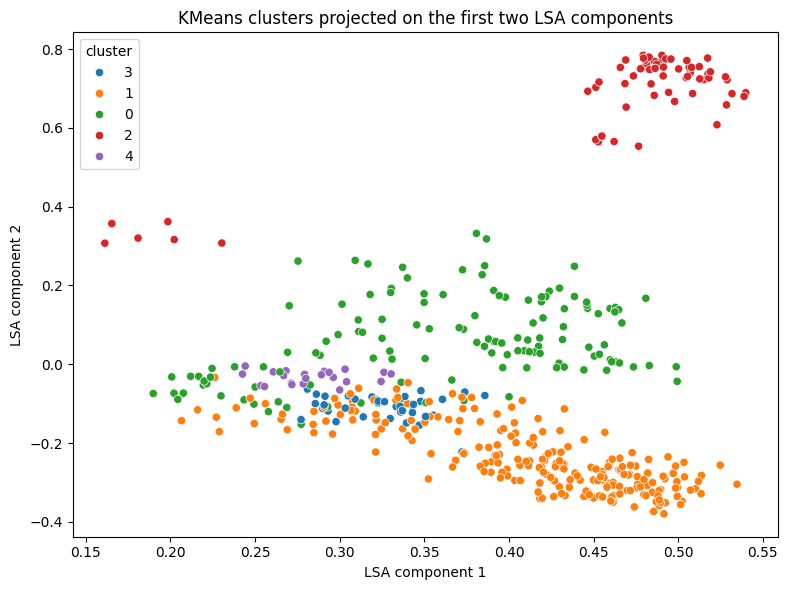

In [29]:
chart_df_2d = pd.DataFrame({
    "topic_1": lsa[:, 0],
    "topic_2": lsa[:, 1],
    "cluster": df_kmeans["kmeans_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=chart_df_2d,
    x="topic_1",
    y="topic_2",
    hue="cluster"
)

plt.title("KMeans clusters projected on the first two LSA components")
plt.xlabel("LSA component 1")
plt.ylabel("LSA component 2")
plt.tight_layout()
plt.show()

The 2D projection shows that some clusters are clearly separated, especially the red and orange groups, while others remain closer to each other.

This suggests that the clustering captures meaningful structure in the product descriptions, although the separation is not equally strong for all groups.

As this is only a 2D projection of a higher-dimensional space, some overlap is expected and does not necessarily mean that the clusters are poorly defined.

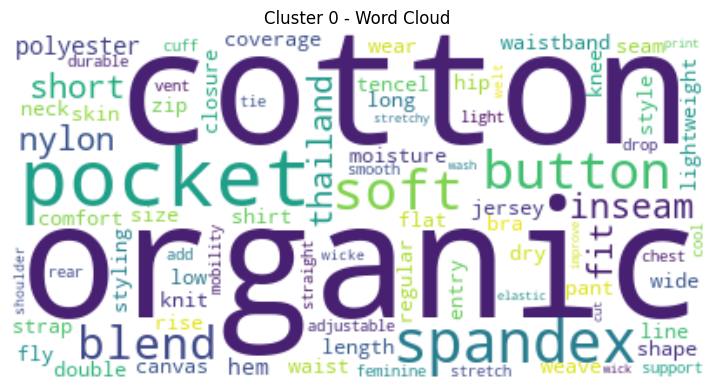

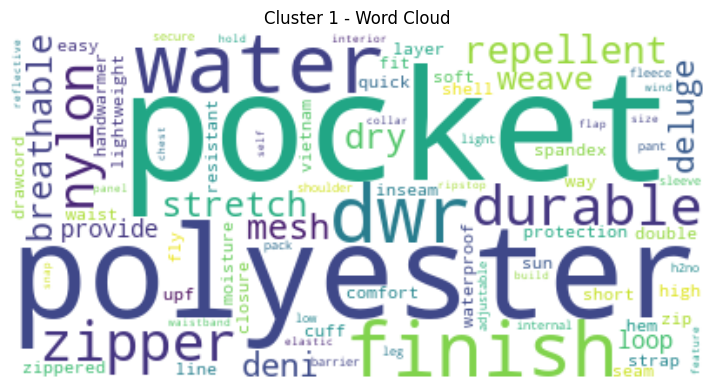

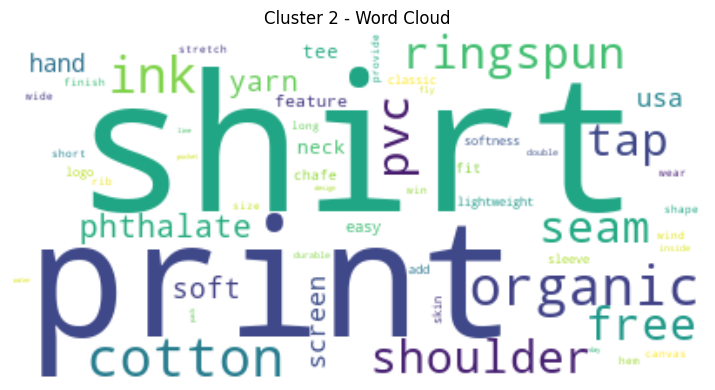

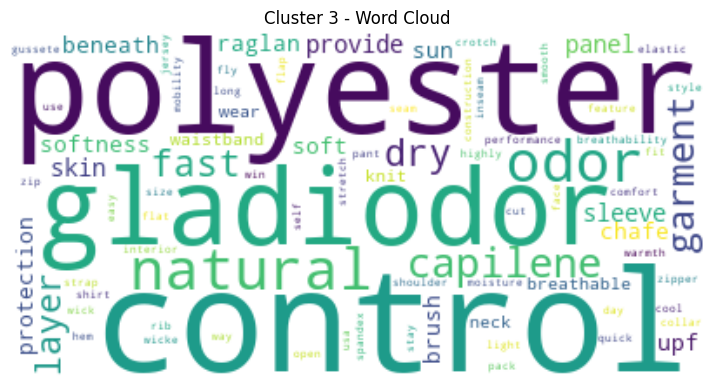

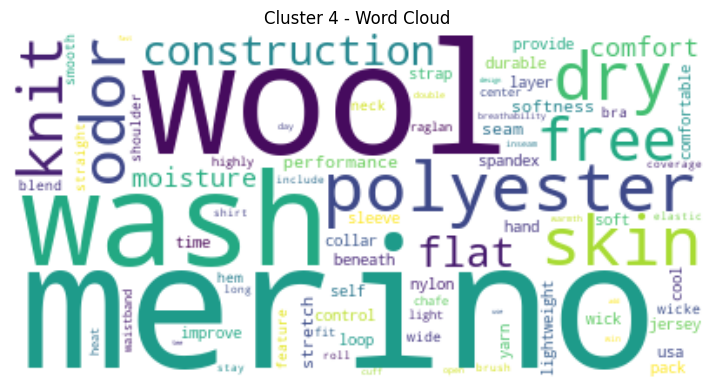

In [31]:
for cluster_id in sorted(df_kmeans["kmeans_cluster"].unique()):
    text = " ".join(
        df_kmeans.loc[df_kmeans["kmeans_cluster"] == cluster_id, "nlp_ready"].dropna()
    ).strip()

    if not text:
        continue

    wordcloud = WordCloud(
        background_color="white",
        max_words=80,
        collocations=False,
        random_state=42
    ).generate(text)

    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster_id} - Word Cloud")
    plt.tight_layout()
    plt.show()

In [32]:
score = silhouette_score(lsa, kmeans.labels_)
print(f"Silhouette score: {score:.2f}")

Silhouette score: 0.21


The silhouette score for the selected KMeans model is **0.21**.

This suggests that the cluster structure is present but only moderately separated.  
Some groups appear clearly distinct, while others remain closer to each other, which is common in text clustering tasks.

#### DBscan

In [33]:
results = []

eps_values = np.arange(0.05, 0.5, 0.05)
min_samples_values = range(5, 20, 1)

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(lsa)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels) * 100

        if n_clusters > 1:
            sil_score = silhouette_score(lsa, labels, metric='cosine')
        else:
            sil_score = -1 

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'noise_pct': noise_pct
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by='silhouette', ascending=False, inplace=True)
results_df.head(10)

,eps,min_samples,n_clusters,silhouette,noise_pct
45,0.20,5,23,0.318348,23.0
65,0.25,10,14,0.291581,28.4
82,0.30,12,9,0.289101,25.4
66,0.25,11,13,0.282171,35.0
64,0.25,9,11,0.278805,27.2
47,0.20,7,18,0.275494,36.8
46,0.20,6,19,0.275399,29.8
60,0.25,5,17,0.274098,9.4
83,0.30,13,8,0.266099,29.0
84,0.30,14,8,0.264330,29.4


Several combinations of `eps` and `min_samples` were tested for DBSCAN.

The results were compared using the number of clusters, the silhouette score, and the percentage of noise points, in order to identify a configuration that remains both meaningful and usable.

Among the tested DBSCAN configurations, the best silhouette score was obtained with a very large number of clusters, which made the result less practical to interpret.

For this reason, the selected configuration was **eps = 0.30** and **min_samples = 12**.  
This setting provides a better balance between cluster quality, number of groups, and noise level, making the clustering result more usable for interpretation and recommendation.

In [34]:
db = DBSCAN(eps=0.3, min_samples=12, metric="cosine")
db.fit(lsa)

np.unique(db.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8])

In [35]:
df_dbscan = data.copy()
df_dbscan = df_dbscan.drop(columns=['desc_clean', 'desc_token_temp', 'nlp_ready_temp', 'desc_token'])
df_dbscan['db_cluster'] = db.fit_predict(lsa)

df_dbscan.head()

,id,description,nlp_ready,db_cluster
0,1,Active classic boxers - There's a reason why o...,classic cool quick dry lightweight pack brush ...,0
1,2,Active sport boxer briefs - Skinning up Glory ...,skin fit breathable polyester fast wicke dry s...,-1
2,3,Active sport briefs - These superbreathable no...,fly high blend fast wicke quick dry polyester ...,-1
3,4,"Alpine guide pants - Skin in, climb ice, switc...",pant skin durable resistant breathable soft sh...,1
4,5,"Alpine wind jkt - On high ridges, steep ice an...",wind high stand shell cool high time tie polye...,1


In [36]:
df_dbscan['db_cluster'].value_counts()

db_cluster
 1    151
-1    127
 3     64
 0     35
 4     27
 2     23
 5     23
 6     22
 8     16
 7     12
Name: count, dtype: int64

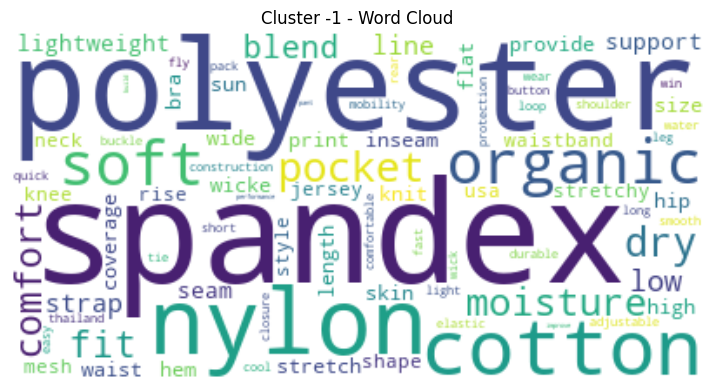

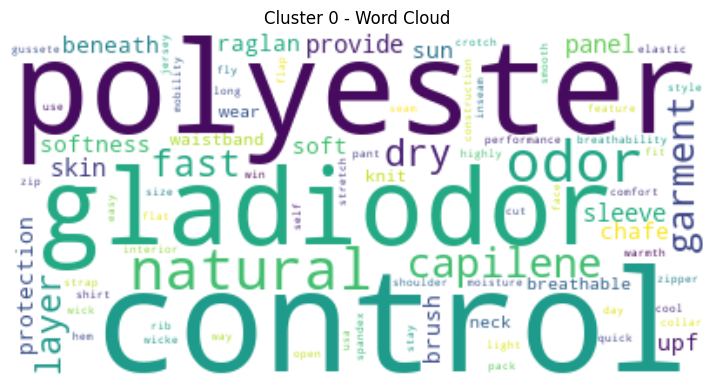

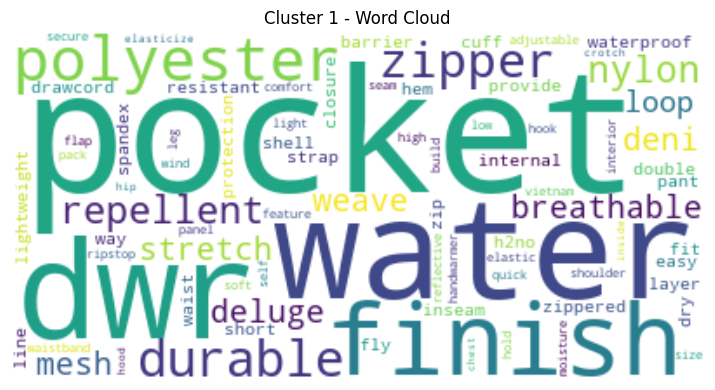

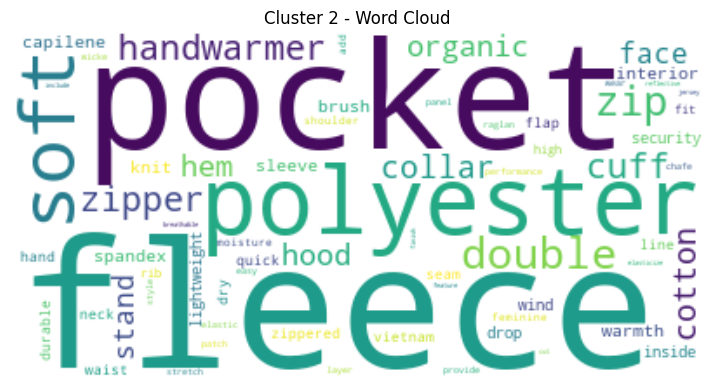

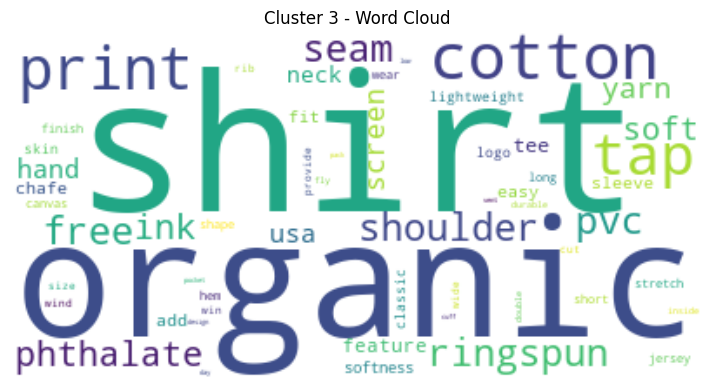

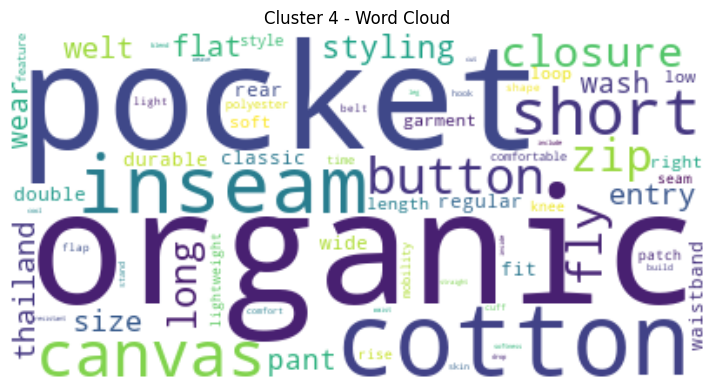

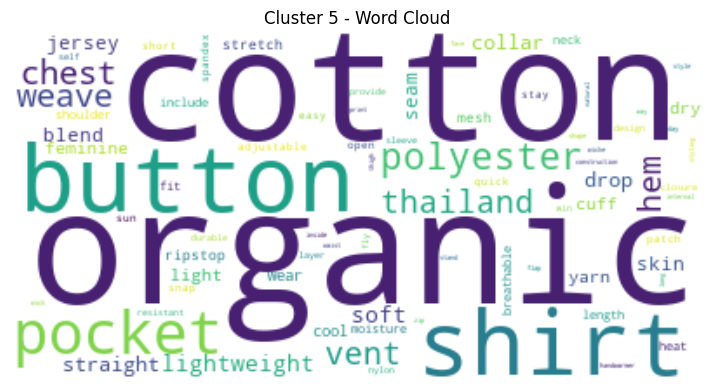

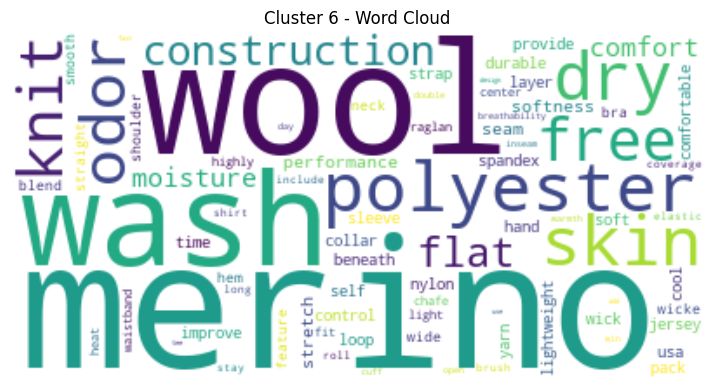

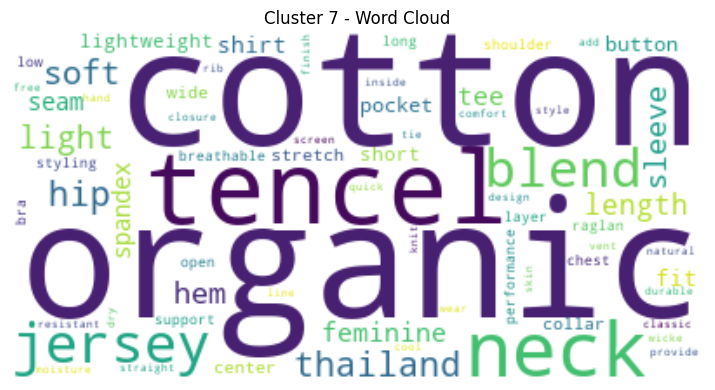

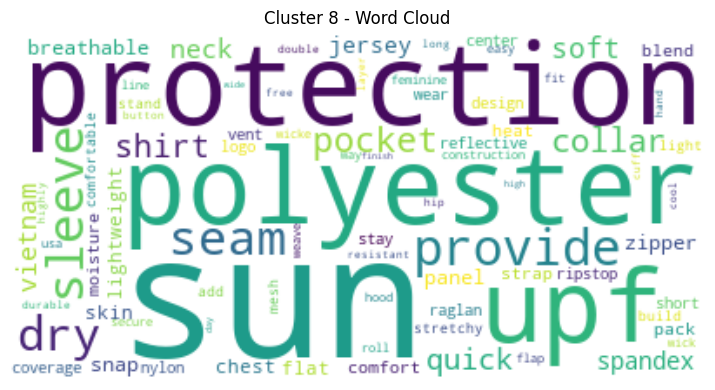

In [37]:
for cluster_id in sorted(df_dbscan['db_cluster'].unique()):
    text = " ".join(
        df_dbscan.loc[df_dbscan['db_cluster'] == cluster_id, "nlp_ready"].dropna()
    ).strip()

    if not text:
        continue

    wordcloud = WordCloud(
        background_color="white",
        max_words=80,
        collocations=False,
        random_state=42
    ).generate(text)

    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster_id} - Word Cloud")
    plt.tight_layout()
    plt.show()

- **KMeans** produced clusters with balanced sizes, but the content of these clusters was sometimes not well differentiated. The silhouette score was acceptable (~0.21), but the wordclouds were occasionally redundant.

- **DBSCAN** generated 8 well-separated clusters and one `-1` cluster for outliers. The **wordclouds per cluster were more expressive** and interpretable.
- The handling of noise (cluster -1) is particularly useful for excluding generic or ambiguous products, or for creating an “other” category.

**DBSCAN was selected** as the main method for the rest of the project. Although it yields clusters with less regular size, the **thematic coherence** of the results was stronger, as demonstrated by the **generated wordclouds**. This makes it more suitable for the recommendation phase.

## 5. Building a Recommendation System

### Goal

The goal of this step is to create a simple recommendation system based on the product clusters.

The idea is to recommend products that belong to the same cluster as the selected item, assuming that products grouped together share similar themes or descriptions.

### What was done

1. **Built a recommendation function**  
   A function was created to retrieve products from the same cluster as a selected item.

2. **Checked product validity**  
   The system verifies whether the product ID exists in the dataset before generating recommendations.

3. **Returned similar products**  
   If the product is found, the function returns a small set of products from the same cluster.

4. **Added a simple user interaction step**  
   A basic input function allows the user to enter a product ID and receive recommendations.

In [41]:
def find_similar_items(item_id, df, cluster_col="db_cluster", n_recommendations=5):
    if item_id not in df["id"].values:
        print(f"{item_id} is not a valid product ID.")
        return None, None

    selected_item = df[df["id"] == item_id]
    selected_cluster = selected_item[cluster_col].values[0]

    recommendations = df[
        (df[cluster_col] == selected_cluster) & (df["id"] != item_id)
    ]

    n_sample = min(n_recommendations, len(recommendations))
    recommendations = recommendations.sample(n=n_sample, random_state=42)

    return selected_item, recommendations


def get_valid_item_id():
    while True:
        user_input = input("Enter a product ID: ")
        try:
            return int(user_input)
        except ValueError:
            print("Please enter a valid number.")


user_item_id = get_valid_item_id()
selected_item, recommendations = find_similar_items(user_item_id, df_dbscan)

if selected_item is not None:
    print("Selected product:")
    display(selected_item[["id", "description", "db_cluster"]])

    print("\nRecommended products:")
    display(recommendations[["id", "description", "db_cluster"]])

Selected product:


,id,description,db_cluster
55,56,Iceberg t-shirt - The effects of global warmin...,3



Recommended products:


,id,description,db_cluster
491,492,Freedom to roam t-shirt - Global warming and h...,3
470,471,"Baby live simply seal t-shirt - Swim, fish, ha...",3
25,26,City by the sea t-shirt - Illustrating the ren...,3
346,347,Vintage logo pkt t-shirt - Keep it on the down...,3
63,64,Gpiw classic t-shirt - Soft-wearing ringspun o...,3


## 6. Conclusion

This project explored product descriptions with NLP in order to group similar items and build a simple recommendation system.

After cleaning and preprocessing the text, the descriptions were transformed into TF-IDF features and reduced with TruncatedSVD. This helped capture the main semantic structure of the catalog and create a more compact representation of the products.

Both **KMeans** and **DBSCAN** were tested.  
In the end, **DBSCAN** was selected because it can detect product groups without fixing the number of clusters in advance and can also identify noise points. Even though it required parameter tuning, it produced meaningful groups that were useful for interpretation and recommendation.

The word clouds made the clusters easier to interpret by showing the most frequent and representative terms in each group. This helped confirm that the clustering captured consistent themes in the product descriptions.

Using these clusters, a simple recommendation system was built. When a product is selected, the system returns other items from the same cluster, providing a basic but practical way to suggest similar products.

### Possible improvements

This project could be extended in several ways:

- combine clustering with **text similarity scores**,
- test richer embeddings beyond TF-IDF,
- improve the display of recommended items,
- build a small interactive application for easier use.

Overall, the project shows how NLP and clustering can be used to better structure a product catalog and support a first recommendation system.